In [1]:
import math
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

from einops import rearrange, repeat

import sys



### Mamba block

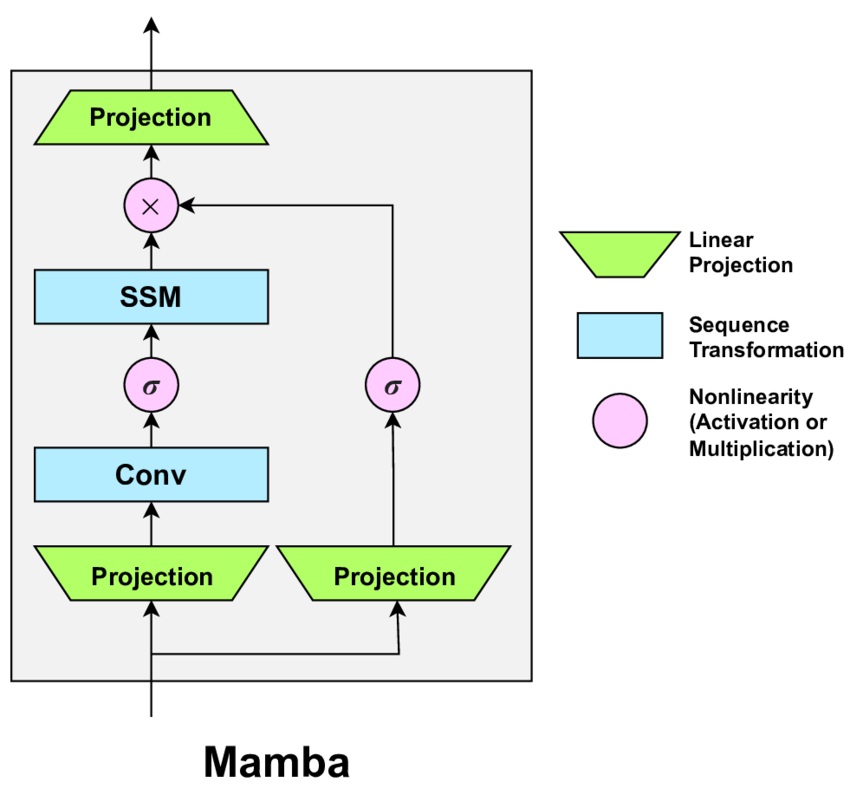

- Take a sequence $x \in \mathbb{R}^{B\times L\times D}$.
- Expand to a bigger inner dimension $D_{inner} = E \cdot D$.
- Apply:
    - a depthwise conv along time for local mixing,
    - a selective SSM (time-varying A,B,C,Δ depending on x),
    - a gate that decides how much of SSM output to keep,
- Then project back to D.

- projections are used to transform the input (typically the hidden states) into different representations.
- The first projection is applied to the input hidden states and splits it into two parts (x and z).
- The last projections are used to bring the output from the SSM (state space model) back to the original hidden state dimensionality.


- The SSM is responsible for modeling the temporal dependencies in the data. It updates the state (represented by h_t), computes the next hidden state, and outputs the result based on the input sequence. The SSM utilizes parameters like A, B, and C (as explained in the paper), which define how the state evolves.

In [27]:

import torch
import torch.nn as nn

class TimePointEmbedding(nn.Module):
    def __init__(self, c_in, d_model):
        """
        c_in: Number of input variables (1 for univariate, M for multivariate)
        d_model: The hidden dimension of your model
        """
        super().__init__()
        # The main projection layer
        self.projection = nn.Linear(c_in, d_model)

    def forward(self, x):
        # x shape: [Batch, Length, c_in]
        # output shape: [Batch, Length, d_model]
        return self.projection(x)


# 1. Multivariate "Mixing" Approach (Classic)
# We have 7 weather features. We want a model dim of 128.
embedder_mix = TimePointEmbedding(c_in=1, d_model=5)
input_data = torch.randn(1, 3, 1) # Batch 32, Length 100, 7 features
tokenized_mix = embedder_mix(input_data) 
print(f"Mixed Shape: {tokenized_mix.shape}") # [32, 100, 128]

# 2. Channel Independent Approach (Modern Trend)
# We reshape data to treat it as 7 separate univariate series
input_independent = input_data.transpose(1, 2).reshape(-1, 3, 1) # [224, 100, 1]
embedder_indep = TimePointEmbedding(c_in=1, d_model=5) # Note c_in=1
tokenized_indep = embedder_indep(input_independent)
print(f"Independent Shape: {tokenized_indep.shape}") # [224, 100, 128]

Mixed Shape: torch.Size([1, 3, 5])
Independent Shape: torch.Size([1, 3, 5])


In [30]:
embedder_mix.projection.weight

Parameter containing:
tensor([[-0.2551],
        [-0.3253],
        [-0.0235],
        [-0.3349],
        [ 0.5337]], requires_grad=True)

In [ ]:
"""Simple, minimal implementation of Mamba in one file of PyTorch.

Suggest reading the following before/while reading the code:
    [1] Mamba: Linear-Time Sequence Modeling with Selective State Spaces (Albert Gu and Tri Dao)
        https://arxiv.org/abs/2312.00752
    [2] The Annotated S4 (Sasha Rush and Sidd Karamcheti)
        https://srush.github.io/annotated-s4

Glossary:
    b: batch size                       (`B` in Mamba paper [1] Algorithm 2)
    l: sequence length                  (`L` in [1] Algorithm 2)
    d or d_model: hidden dim            Number of Parallel SSMs
    n or d_state: latent state dim      (`N` in [1] Algorithm 2)
    expand: expansion factor            (`E` in [1] Section 3.4)
    d_in or d_inner: d * expand         (`D` in [1] Algorithm 2)
    A, B, C, D: state space parameters  (See any state space representation formula)
                                        (B, C are input-dependent (aka selective, a key innovation in Mamba); A, D are not)
    Δ or delta: input-dependent step size
    dt_rank: rank of Δ                  (See [1] Section 3.6 "Parameterization of ∆")

"""
from __future__ import annotations
import math
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from einops import rearrange, repeat, einsum


@dataclass
class ModelArgs:
    d_model: int
    n_layer: int
    c_in: int
    # vocab_size: int
    d_state: int = 16
    expand: int = 2
    dt_rank: Union[int, str] = 'auto'
    d_conv: int = 4 
    # pad_vocab_size_multiple: int = 8
    conv_bias: bool = True
    bias: bool = False
    
    def __post_init__(self):
        # expanding the input dimension by a factor of expand
        self.d_inner = int(self.expand * self.d_model)
        
        if self.dt_rank == 'auto':
            self.dt_rank = math.ceil(self.d_model / 16)
            
        #TODO: Remove or update this to be suitable for the time series case.
        #if self.vocab_size % self.pad_vocab_size_multiple != 0:
        #    self.vocab_size += (self.pad_vocab_size_multiple
        #                        - self.vocab_size % self.pad_vocab_size_multiple)


class Mamba(nn.Module):
    def __init__(self, args: ModelArgs):
        """Full Mamba model."""
        super().__init__()
        self.args = args
        
        # self.embedding = nn.Embedding(args.vocab_size, args.d_model)
        # projecting the time series data to the embedding space, as each 1 time step is a token with d_model dimensions. and weights can be accessed as direct_tokenizer.projection.weight.
        self.direct_tokenizer = TimePointEmbedding(c_in=1, d_model= args.d_model)

        self.layers = nn.ModuleList([ResidualBlock(args) for _ in range(args.n_layer)])
        self.norm_f = RMSNorm(args.d_model)

        # # Output a scalar value for each time step
        self.lm_head = nn.Linear(args.d_model, 1)
        # self.lm_head.weight = self.direct_tokenizer.projection.weight  # Tie output projection to embedding weights.


    def forward(self, input_ids):
        """
        Args:
            input_ids (long tensor): shape (b, l)    (See Glossary at top for definitions of b, l, d_in, n...)
    
        Returns:
            logits: shape (b, l, vocab_size)

        Official Implementation:
            class MambaLMHeadModel, https://github.com/state-spaces/mamba/blob/main/mamba_ssm/models/mixer_seq_simple.py#L173

        """
        # x = self.embedding(input_ids)
        # input_ids is the time series data with shape (b, l) 
        x = self.direct_tokenizer(input_ids) # resulting shape (b, l, d_model), the same as the embedding does.
        
        for layer in self.layers:
            x = layer(x)
            
        x = self.norm_f(x)
        logits = self.lm_head(x) # Output scalar values instead of logits for tokens

        return logits


    # TODO: Enable pretrained model loading from existing time series models, but in the future.    
    # @staticmethod
    # def from_pretrained(pretrained_model_name: str):
    #     """Load pretrained weights from HuggingFace into model.
    
    #     Args:
    #         pretrained_model_name: One of
    #             * 'state-spaces/mamba-2.8b-slimpj'
    #             * 'state-spaces/mamba-2.8b'
    #             * 'state-spaces/mamba-1.4b'
    #             * 'state-spaces/mamba-790m'
    #             * 'state-spaces/mamba-370m'
    #             * 'state-spaces/mamba-130m'
                            
    #     Returns:
    #         model: Mamba model with weights loaded
    
    #     """
    #     from transformers.utils import WEIGHTS_NAME, CONFIG_NAME
    #     from transformers.utils.hub import cached_file
        
    #     def load_config_hf(model_name):
    #         resolved_archive_file = cached_file(model_name, CONFIG_NAME,
    #                                             _raise_exceptions_for_missing_entries=False)
    #         return json.load(open(resolved_archive_file))
        
        
    #     def load_state_dict_hf(model_name, device=None, dtype=None):
    #         resolved_archive_file = cached_file(model_name, WEIGHTS_NAME,
    #                                             _raise_exceptions_for_missing_entries=False)
    #         return torch.load(resolved_archive_file, weights_only=True, map_location='cpu', mmap=True)
        
    #     config_data = load_config_hf(pretrained_model_name)
    #     args = ModelArgs(
    #         d_model=config_data['d_model'],
    #         n_layer=config_data['n_layer'],
    #         vocab_size=config_data['vocab_size']
    #     )
    #     model = Mamba(args)
        
    #     state_dict = load_state_dict_hf(pretrained_model_name)
    #     new_state_dict = {}
    #     for key in state_dict:
    #         new_key = key.replace('backbone.', '')
    #         new_state_dict[new_key] = state_dict[key]
    #     model.load_state_dict(new_state_dict)
        
    #     return model


class ResidualBlock(nn.Module):
    def __init__(self, args: ModelArgs):
        """Simple block wrapping Mamba block with normalization and residual connection."""
        super().__init__()
        self.args = args
        self.mixer = MambaBlock(args)
        self.norm = RMSNorm(args.d_model)
        

    def forward(self, x):
        """
        Args:
            x: shape (b, l, d)    (See Glossary at top for definitions of b, l, d_in, n...)
    
        Returns:
            output: shape (b, l, d)

        Official Implementation:
            Block.forward(), https://github.com/state-spaces/mamba/blob/main/mamba_ssm/modules/mamba_simple.py#L297
            
            Note: the official repo chains residual blocks that look like
                [Add -> Norm -> Mamba] -> [Add -> Norm -> Mamba] -> [Add -> Norm -> Mamba] -> ...
            where the first Add is a no-op. This is purely for performance reasons as this
            allows them to fuse the Add->Norm.

            We instead implement our blocks as the more familiar, simpler, and numerically equivalent
                [Norm -> Mamba -> Add] -> [Norm -> Mamba -> Add] -> [Norm -> Mamba -> Add] -> ....
            
        """
        output = self.mixer(self.norm(x)) + x

        return output
            

class MambaBlock(nn.Module):
    def __init__(self, args: ModelArgs):
        """A single Mamba block, as described in Figure 3 in Section 3.4 in the Mamba paper [1]."""
        super().__init__()
        self.args = args

        # projecting the d_model into two d_inner, for two linear layers (conv+ssm, residual)
        self.in_proj = nn.Linear(args.d_model, args.d_inner * 2, bias=args.bias)

        self.conv1d = nn.Conv1d(
            in_channels=args.d_inner,
            out_channels=args.d_inner,
            bias=args.conv_bias,
            kernel_size=args.d_conv,
            groups=args.d_inner,
            padding=args.d_conv - 1,
        )

        # "Selection Mechanism" in Mamba paper [1], section 3.1
        # x_proj takes in `x` and outputs the input-specific Δ, B, C
        self.x_proj = nn.Linear(args.d_inner, args.dt_rank + args.d_state * 2, bias=False)
        
        # dt_proj projects Δ from dt_rank to d_in. Low-Rank factorization of Delta (Δ), Δ controls the "speed" or "step size" of the memory.
        self.dt_proj = nn.Linear(args.dt_rank, args.d_inner, bias=True)

        # initialization and stability enforcement of the Matrix A. A is Diagonal
        A = repeat(torch.arange(1, args.d_state + 1), 'n -> d n', d=args.d_inner)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(args.d_inner))
        self.out_proj = nn.Linear(args.d_inner, args.d_model, bias=args.bias)
        

    def forward(self, x):
        """Mamba block forward. This looks the same as Figure 3 in Section 3.4 in the Mamba paper [1].
    
        Args:
            x: shape (b, l, d)    (See Glossary at top for definitions of b, l, d_in, n...)
    
        Returns:
            output: shape (b, l, d)
        
        Official Implementation:
            class Mamba, https://github.com/state-spaces/mamba/blob/main/mamba_ssm/modules/mamba_simple.py#L119
            mamba_inner_ref(), https://github.com/state-spaces/mamba/blob/main/mamba_ssm/ops/selective_scan_interface.py#L311
            
        """
        (b, l, d) = x.shape
        
        x_and_res = self.in_proj(x)  # shape (b, l, 2 * d_in)
        (x, res) = x_and_res.split(split_size=[self.args.d_inner, self.args.d_inner], dim=-1)

        x = rearrange(x, 'b l d_in -> b d_in l')
        x = self.conv1d(x)[:, :, :l]
        x = rearrange(x, 'b d_in l -> b l d_in')
        
        x = F.silu(x)

        y = self.ssm(x)
        
        y = y * F.silu(res)
        
        output = self.out_proj(y)

        return output

    
    def ssm(self, x):
        """Runs the SSM. See:
            - Algorithm 2 in Section 3.2 in the Mamba paper [1]
            - run_SSM(A, B, C, u) in The Annotated S4 [2]

        Args:
            x: shape (b, l, d_in)    (See Glossary at top for definitions of b, l, d_in, n...)
    
        Returns:
            output: shape (b, l, d_in)

        Official Implementation:
            mamba_inner_ref(), https://github.com/state-spaces/mamba/blob/main/mamba_ssm/ops/selective_scan_interface.py#L311
            
        """
        (d_in, n) = self.A_log.shape

        # Compute ∆ A B C D, the state space parameters.
        #     A, D are input independent (see Mamba paper [1] Section 3.5.2 "Interpretation of A" for why A isn't selective)
        #     ∆, B, C are input-dependent (this is a key difference between Mamba and the linear time invariant S4,
        #                                  and is why Mamba is called **selective** state spaces)
        
        A = -torch.exp(self.A_log.float())  # shape (d_in, n)
        D = self.D.float()

        x_dbl = self.x_proj(x)  # (b, l, dt_rank + 2*n)
        
        (delta, B, C) = x_dbl.split(split_size=[self.args.dt_rank, n, n], dim=-1)  # delta: (b, l, dt_rank). B, C: (b, l, n)
        delta = F.softplus(self.dt_proj(delta))  # (b, l, d_in)
        
        y = self.selective_scan(x, delta, A, B, C, D)  # This is similar to run_SSM(A, B, C, u) in The Annotated S4 [2]
        
        return y

    
    def selective_scan(self, u, delta, A, B, C, D):
        """Does selective scan algorithm. See:
            - Section 2 State Space Models in the Mamba paper [1]
            - Algorithm 2 in Section 3.2 in the Mamba paper [1]
            - run_SSM(A, B, C, u) in The Annotated S4 [2]

        This is the classic discrete state space formula:
            x(t + 1) = Ax(t) + Bu(t)
            y(t)     = Cx(t) + Du(t)
        except B and C (and the step size delta, which is used for discretization) are dependent on the input x(t).
    
        Args:
            u: shape (b, l, d_in)    (See Glossary at top for definitions of b, l, d_in, n...)
            delta: shape (b, l, d_in)
            A: shape (d_in, n)
            B: shape (b, l, n)
            C: shape (b, l, n)
            D: shape (d_in,)
    
        Returns:
            output: shape (b, l, d_in)
    
        Official Implementation:
            selective_scan_ref(), https://github.com/state-spaces/mamba/blob/main/mamba_ssm/ops/selective_scan_interface.py#L86
            Note: I refactored some parts out of `selective_scan_ref` out, so the functionality doesn't match exactly.
            
        """
        (b, l, d_in) = u.shape
        n = A.shape[1]
        
        # Discretize continuous parameters (A, B)
        # - A is discretized using zero-order hold (ZOH) discretization (see Section 2 Equation 4 in the Mamba paper [1])
        # - B is discretized using a simplified Euler discretization instead of ZOH. From a discussion with authors:
        #   "A is the more important term and the performance doesn't change much with the simplification on B"
        deltaA = torch.exp(einsum(delta, A, 'b l d_in, d_in n -> b l d_in n'))
        deltaB_u = einsum(delta, B, u, 'b l d_in, b l n, b l d_in -> b l d_in n')
        
        # Perform selective scan (see scan_SSM() in The Annotated S4 [2])
        # Note that the below is sequential, while the official implementation does a much faster parallel scan that
        # is additionally hardware-aware (like FlashAttention).
        x = torch.zeros((b, d_in, n), device=deltaA.device)
        ys = []    
        for i in range(l):
            x = deltaA[:, i] * x + deltaB_u[:, i]
            y = einsum(x, C[:, i, :], 'b d_in n, b n -> b d_in')
            ys.append(y)
        y = torch.stack(ys, dim=1)  # shape (b, l, d_in)
        
        y = y + u * D
    
        return y


class RMSNorm(nn.Module):
    def __init__(self,
                 d_model: int,
                 eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))


    def forward(self, x):
        output = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

        return output
        

In [3]:
from transformers import AutoTokenizer

# One of:
#     'state-spaces/mamba-2.8b-slimpj'
#     'state-spaces/mamba-2.8b'
#     'state-spaces/mamba-1.4b'
#     'state-spaces/mamba-790m'
#     'state-spaces/mamba-370m'
#     'state-spaces/mamba-130m'
pretrained_model_name = 'state-spaces/mamba-370m'

model = Mamba.from_pretrained(pretrained_model_name)
tokenizer = AutoTokenizer.from_pretrained('EleutherAI/gpt-neox-20b')

/home/muhammadhassan/DSIPTS/env_3_11_13/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import torch
import torch.nn.functional as F


def generate(model,
             tokenizer,
             prompt: str,
             n_tokens_to_gen: int = 50,
             sample: bool = True,
             top_k: int = 40):
    model.eval()
    
    input_ids = tokenizer(prompt, return_tensors='pt').input_ids
    
    for token_n in range(n_tokens_to_gen):
        with torch.no_grad():
            indices_to_input = input_ids
            next_token_logits = model(indices_to_input)[:, -1]
        
        probs = F.softmax(next_token_logits, dim=-1)
        (batch, vocab_size) = probs.shape
        
        if top_k is not None:
            (values, indices) = torch.topk(probs, k=top_k)
            probs[probs < values[:, -1, None]] = 0
            probs = probs / probs.sum(axis=1, keepdims=True)
        
        if sample:
            next_indices = torch.multinomial(probs, num_samples=1)
        else:
            next_indices = torch.argmax(probs, dim=-1)[:, None]
        
        input_ids = torch.cat([input_ids, next_indices], dim=1)

    output_completions = [tokenizer.decode(output.tolist()) for output in input_ids][0]
    
    return output_completions

In [6]:
print(generate(model, tokenizer, 'Mamba is the'))

Mamba is the only animal who has a real life to be a mythical creature."

In addition to the three books, there are also six online resources to help you become a better hunter.

"Our aim is to help people who are interested in


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Generate a sine wave with added white noise
def generate_sine_wave_with_noise(seq_len, freq=0.5, noise_std=0.1):
    # This creates a step size of 200/10000 = 0.02, allowing for a smooth wave
    duration = 200 
    t = np.linspace(0, duration, seq_len, endpoint=False)
    
    # Generate the sine wave
    sine_wave = np.sin(2 * np.pi * freq * t)
    
    # Add white noise
    noise = np.random.normal(0, noise_std, seq_len)
    
    # Final signal with noise
    noisy_signal = sine_wave + noise
    return noisy_signal, sine_wave, noise

# Parameters
seq_len = 10000  # 10,000 points
batch_size = 32  # Use a batch size of 32 for testing
input_dim = 1    # Input has 1 feature (the sine wave with noise)

# Generate fake data
fake_data, sine_wave, noise = generate_sine_wave_with_noise(seq_len=seq_len)

# Prepare the input for the Mamba model (batch_size, seq_len, input_dim)
fake_data = torch.tensor(fake_data, dtype=torch.float32).unsqueeze(-1).repeat(batch_size, 1, 1)  # Shape (batch_size, seq_len, 1)
sine_wave = torch.tensor(sine_wave, dtype=torch.float32).unsqueeze(-1).repeat(batch_size, 1, 1)  # Shape (batch_size, seq_len, 1)
noise = torch.tensor(noise, dtype=torch.float32).unsqueeze(-1).repeat(batch_size, 1, 1)  # Shape (batch_size, seq_len, 1)


Text(0.5, 1.0, 'Fake Data')

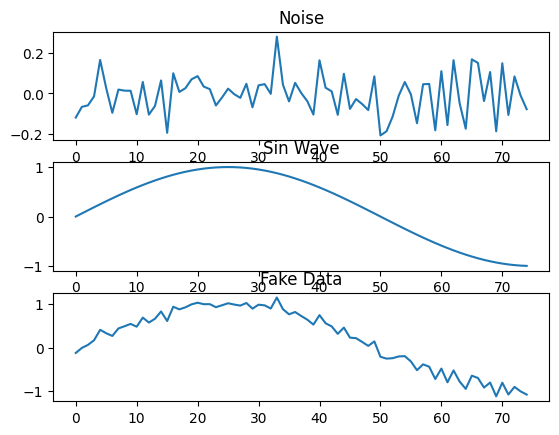

In [4]:
# plot one batch of fake data
plt.subplot(3, 1, 1)
plt.plot(noise[0][:75])
plt.title("Noise")

plt.subplot(3, 1, 2)
plt.plot(sine_wave[0][:75])
plt.title("Sin Wave")

plt.subplot(3, 1, 3)
plt.plot(fake_data[0][:75])
plt.title("Fake Data")




In [5]:
model = Mamba(d_model=input_dim, d_state=16, d_conv=4, expand=2, dt_rank=16)  # Adjust the parameters based on your model

output = model(fake_data)

NameError: name 'causal_conv1d_fn' is not defined

In [ ]:


# Plot the first sequence (1 batch) from the output
# This will help visualize how the model processes the sine wave.
# For simplicity, let's just print the output shape for now.
# You can visualize the output after running it through the model:
# output = output.detach().cpu().numpy()

# plt.plot(fake_data[0, :, 0].cpu().numpy(), label="Input: Sine Wave with Noise")
# plt.plot(output[0, :, 0], label="Output from Mamba Model", linestyle="--")
# plt.legend()
# plt.title("Sine Wave with Noise - Model Output vs Input")
# plt.show()

# To check if the model works without any errors, uncomment the lines below:
# print(f"Input shape: {fake_data.shape}")
# print(f"Output shape: {output.shape}")

